In [1]:
import os, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
from py_util_dx.py_utils import setProjectPath
from py_util_dx.data_utils import get_roi_vtx_from_fs32k, get_roi_pacels, get_glasser_labels
from scipy.stats import ttest_1samp
import Functional_Fusion.atlas_map as am 
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import matplotlib as mpl 
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
import nibabel as nib
from visualizations import flatmap_real_vals
from nitools.cifti import surf_from_cifti
import nitools as nt 

%matplotlib inline 

In [2]:
mpl.rcParams['font.family'] = 'helvetica'   # Global font family
mpl.rcParams['font.size'] = 12              # Global font size 
full_width = 8.5
half_width = full_width/2

In [3]:
projectPath, mainResultsPath = setProjectPath()
# dataset_name = 'MDTB' # or Demand
# dataset_name = 'HCPur100'
dataset_name = 'Language'
# dataset_name = 'Nishimoto'
# dataset_name = 'IBC'
surface_helpers_dir = os.path.join(projectPath, 'surface_helpers')
resultsPath = os.path.join(mainResultsPath, 'START_A7_spatialACF_map_LH', f'{dataset_name}')

PKL_output_LH = os.path.join(resultsPath, f'output_{dataset_name}.pkl')
output_LH = {}

In [4]:
# glasser_L = os.path.join(surface_helpers_dir, 'glasser.L.label.gii')
# gii_file = nib.load(glasser_L)
# parcels_inds = gii_file.darrays[0].data
atlas_str = 'fs32k'
atlas, ainf = am.get_atlas(atlas_str)

In [5]:
# PKL_data = os.path.join(projectPath, 'data', f'{dataset_name}_CondHalf_ses-s2.pkl')

if dataset_name == 'MDTB':
    PKL_data = os.path.join(projectPath, 'data', f'{dataset_name}_CondHalf_ses-s2.pkl')
else:
    PKL_data = os.path.join(projectPath, 'data', f'{dataset_name}_CondHalf_all.pkl')

with open(PKL_data, 'rb') as pf:
    original_data = pickle.load(pf)
    X_individuals = original_data['X_individuals']

n_subjects, _, P = X_individuals.shape
FWHM_map = -1 * np.ones((n_subjects, P))  

In [6]:
PKL_output = os.path.join(resultsPath, f'output_LH_cv.pkl')
included_vtx_inds_LR, included_vtx_inds_L, included_vtx_inds_R, excluded_vtx_inds_LR = get_roi_vtx_from_fs32k('whole_cortex') 

with open(PKL_output, 'rb') as pf:
    output = pickle.load(pf) 
    FWHMs_across_subjects = output['FWHMs_across_subjects'] 

FWHM_map[:, included_vtx_inds_L] = FWHMs_across_subjects 

In [7]:
example_subjects = np.arange(n_subjects)
# example_subjects = np.arange(3)
vmin=0
vmax = 120
cmap = plt.cm.Reds_r
cmap.set_under('white')

output_LH['FWHM_map'] = FWHM_map
output_LH['vmin'] = vmin
output_LH['vmax'] = vmax

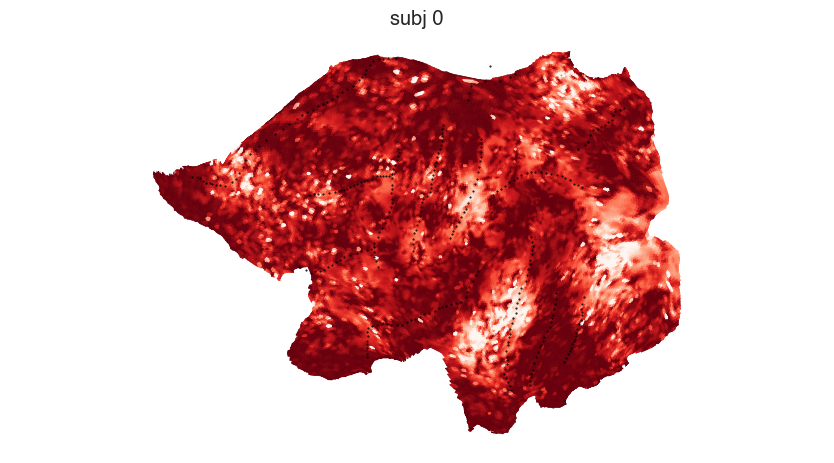

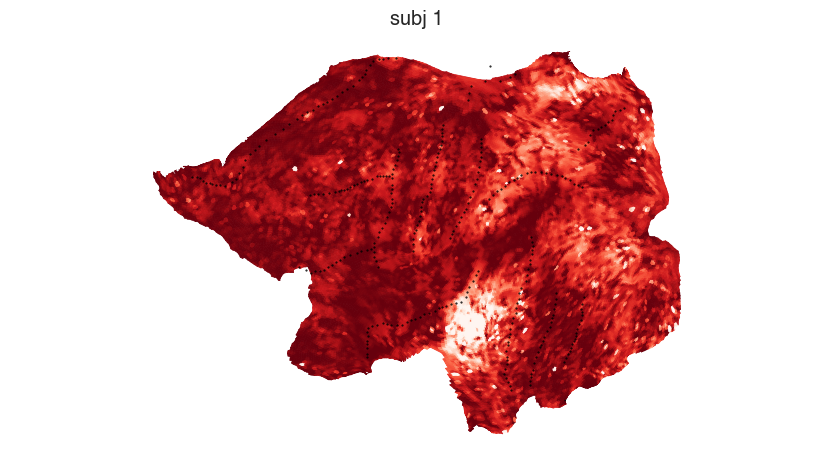

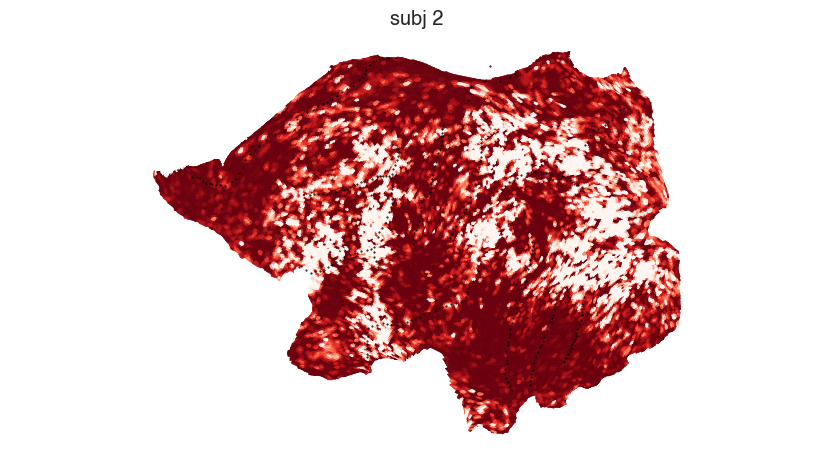

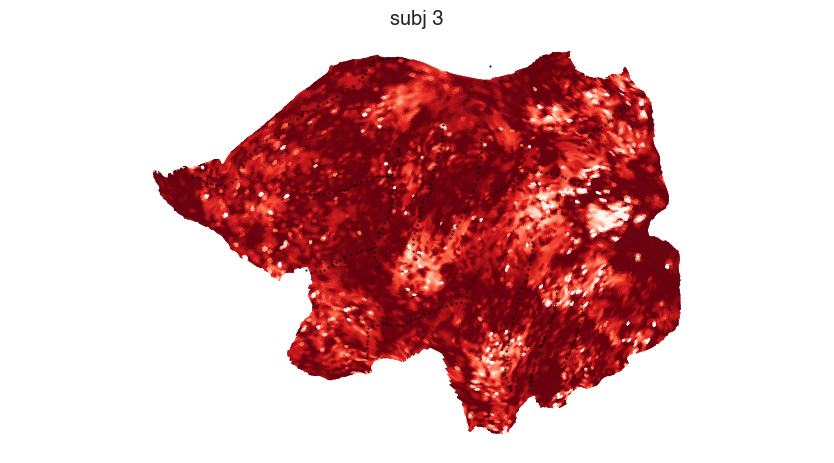

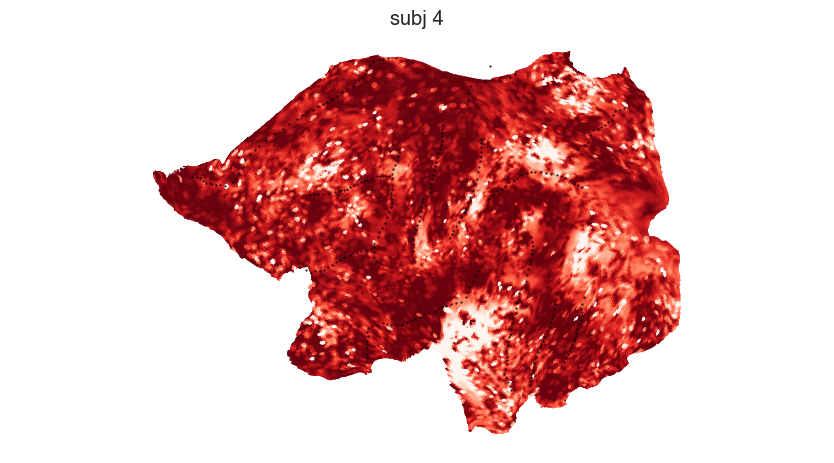

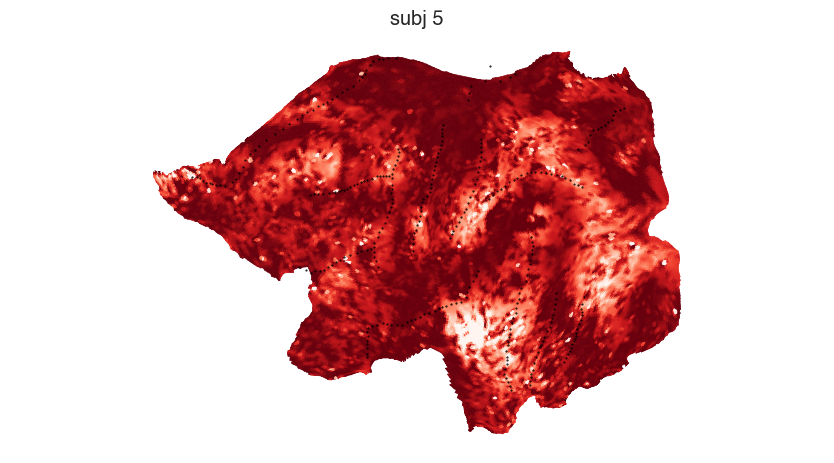

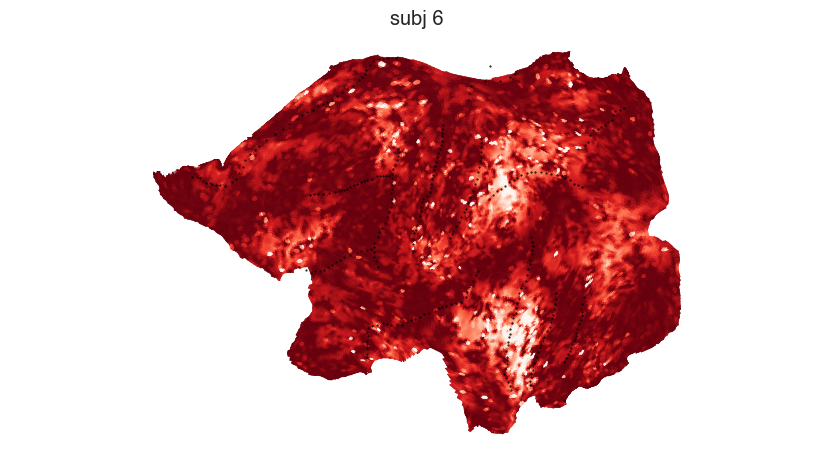

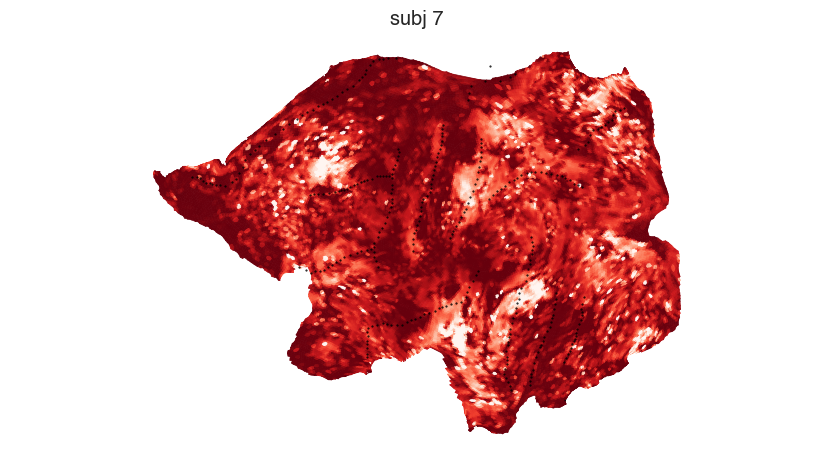

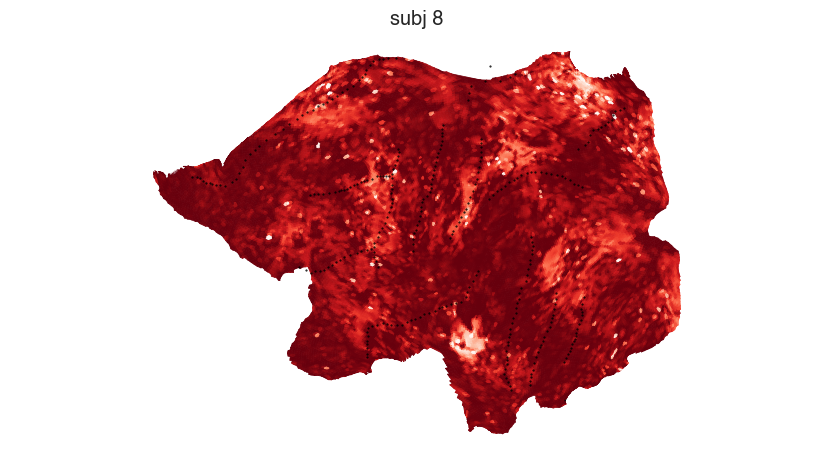

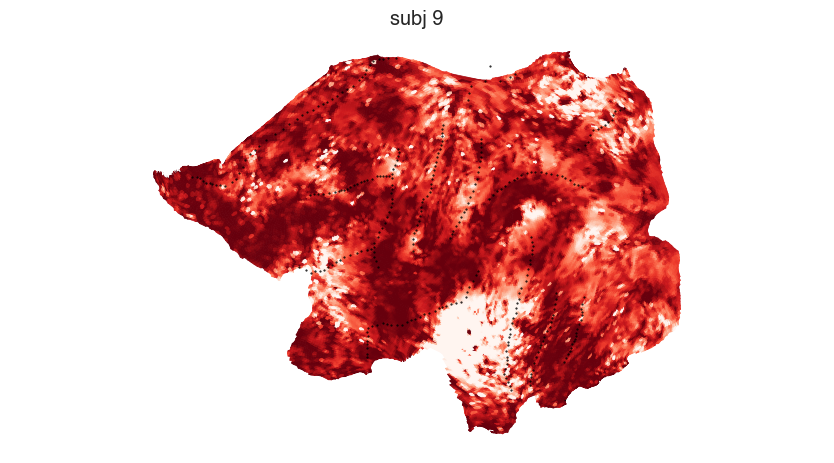

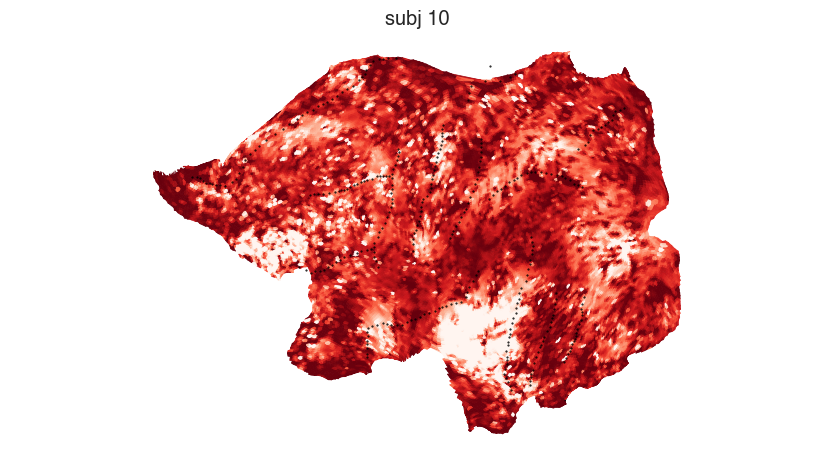

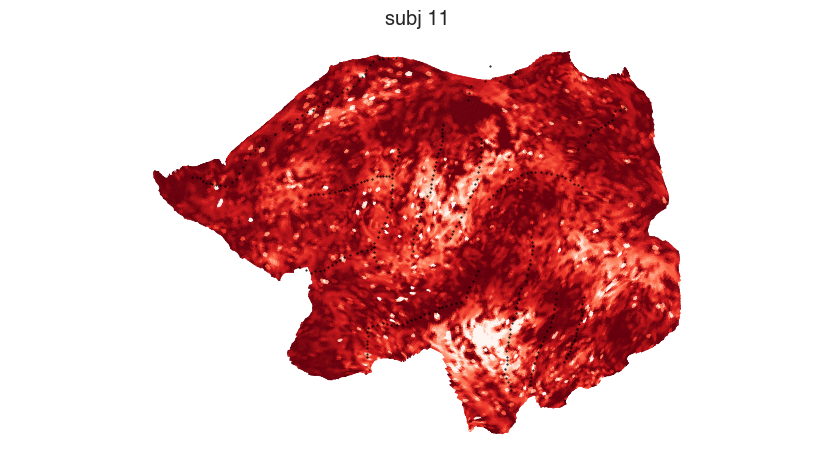

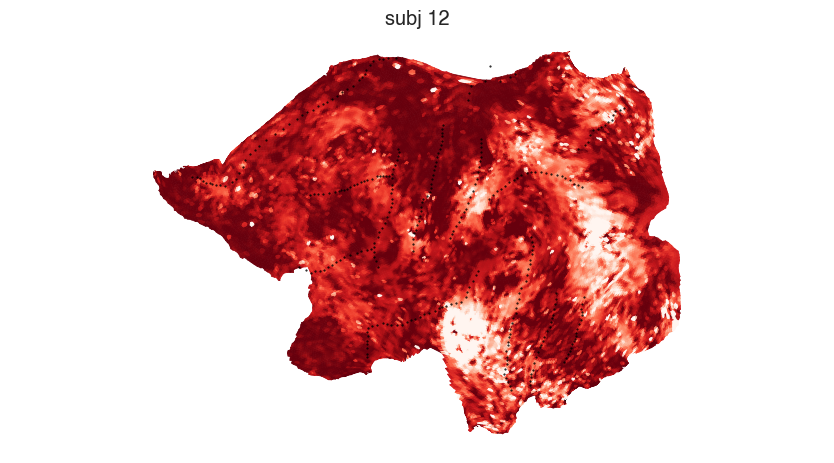

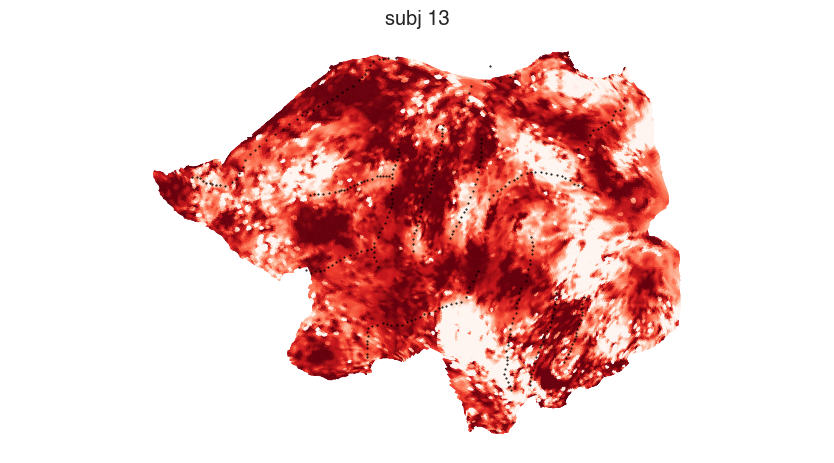

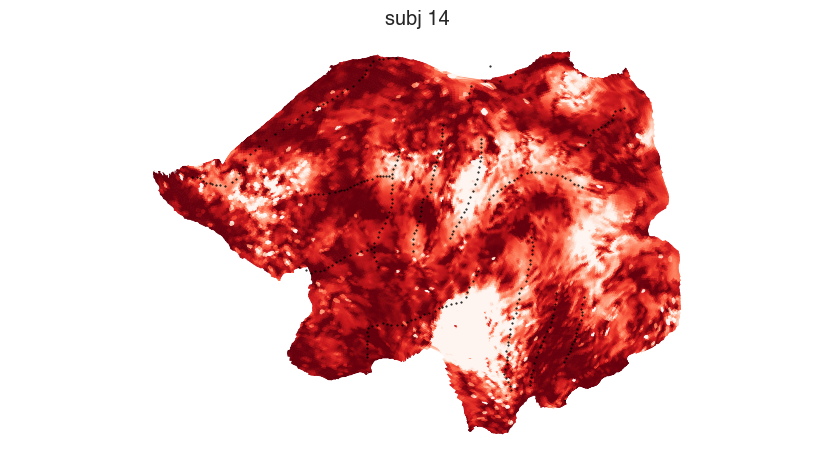

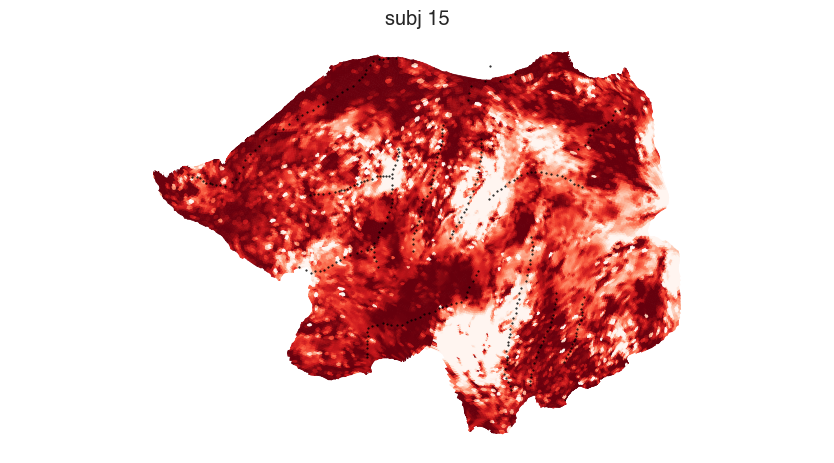

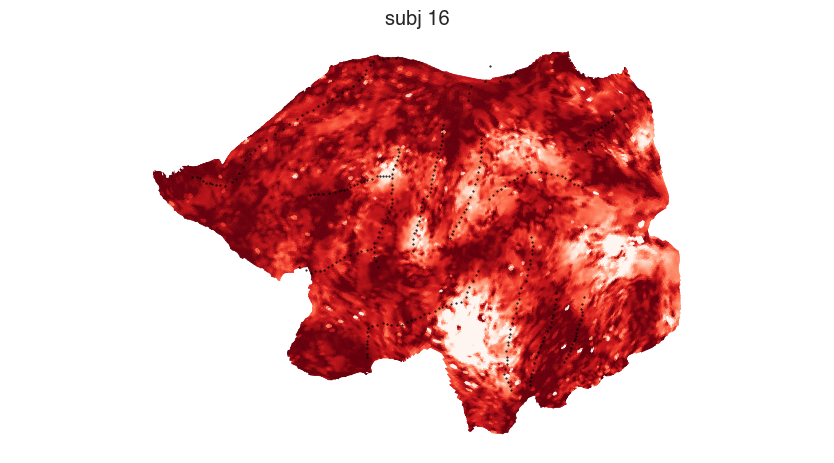

In [8]:
for subjI in np.arange(len(example_subjects)):
    fig, ax = plt.subplots(1, 1)  
    fig.set_figwidth(full_width)

    flatmap_real_vals(FWHM_map[example_subjects[subjI]], 'L', cscale=[vmin, vmax], cmap=cmap) 
    
    ax.set_title(f'subj {example_subjects[subjI]}') 
    plt.tight_layout() 

    JPG_fwhm_map = os.path.join(resultsPath, f'FWHM_map_subj_{example_subjects[subjI]}.jpg')
    plt.savefig(JPG_fwhm_map, format='jpg', dpi=500)

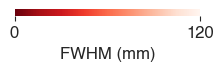

In [9]:
fig, ax = plt.subplots(figsize=(half_width/2, 0.6), layout='constrained')

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
                    cax=ax, orientation='horizontal', label= 'FWHM (mm)', ticks=[vmin, vmax], fraction=0.9) 
cbar.outline.set_visible(False) 
cbar.ax.tick_params(labelsize=12)

JPG_fig = os.path.join(resultsPath, 'cbar_FWHM_maps.jpg')
plt.savefig(JPG_fig, format='jpg', dpi=500) 

In [10]:
print(np.min(FWHM_map))
print(np.max(FWHM_map))

-1300033899.986904
105220.72577706145


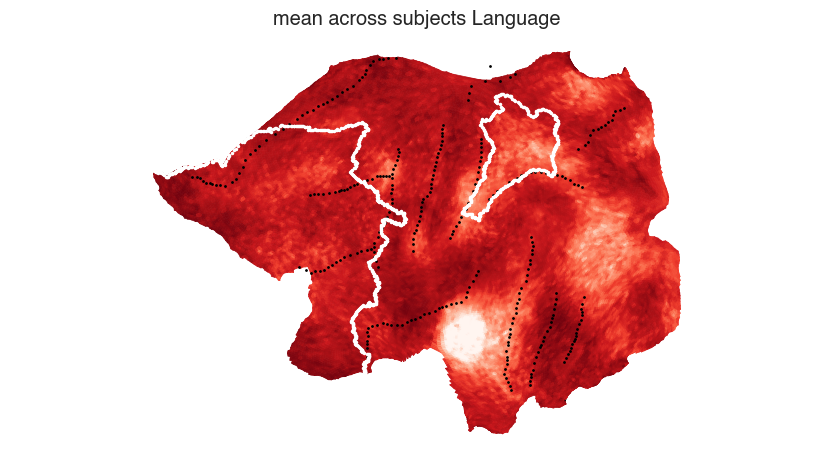

In [11]:
## mean across subjects
fig, ax = plt.subplots(1, 1)
fig.set_figwidth(full_width)

FWHMs_map_mean = FWHM_map.copy()
FWHMs_map_mean[FWHMs_map_mean>500] = np.nan
FWHMs_map_mean[FWHMs_map_mean<-1] = np.nan
FWHMs_map_mean = np.nanmean(FWHMs_map_mean, axis=0)

border_file = os.path.join(surface_helpers_dir, 'fs_LR.32k.L.border')

ax = flatmap_real_vals(FWHMs_map_mean, 'L', cscale=[vmin, vmax], cmap=cmap, borders=border_file, bordersize=2)

border_file = os.path.join(surface_helpers_dir, f'roi_borders_v1.border')

border_list,_ = nt.read_borders(border_file)
flatsurf = nib.load(os.path.join(surface_helpers_dir, 'fs_LR.32k.L.flat.surf.gii')) 
borders = [b.get_coords(flatsurf) for b in border_list]
borders = np.vstack(borders)
ax.plot(borders[:,0],borders[:,1],color='w',
                marker='.', linestyle=None,
                markersize=3,linewidth=0)

ax.set_title(f'mean across subjects {dataset_name}')
plt.tight_layout()

JPG_fwhm_map = os.path.join(resultsPath, f'FWHM_map_mean_across_subjects.jpg')
plt.savefig(JPG_fwhm_map, format='jpg', dpi=500)

In [12]:
print(FWHMs_map_mean.min())
print(FWHMs_map_mean.max())

-1.0
215.48915003175748


In [13]:
with open(PKL_output_LH, 'wb') as pf:
    pickle.dump(output_LH, pf)